# 04. churn_any 교차검증 및 튜닝

In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import GroupKFold, ParameterGrid, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# 한글 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 17)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1,age1_tminus1,income1_tminus1,job1_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0,43,7,1
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0,44,8,1
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0,45,8,1
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,46,9,1
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,47,9,1


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']


## [ 데이터 확인 ]

- 목적: 학습 데이터가 정상적으로 불러와졌는지, 분석에 필요한 핵심 컬럼이 포함되어 있는지 확인한다.
- 목표: 이후 전처리와 모델링 셀에서 사용할 데이터 구조가 맞는지 빠르게 점검한다.


In [3]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰 구분",
    "a03024_tminus1": "음성 무제한 서비스 가입 여부",
    "a03026_tminus1": "데이터 무제한 서비스 가입 여부",
    "c01002_tminus1": "월평균 휴대폰 이용 총 금액",
    "c01004_tminus1": "월평균 기기 할부금",
    "c02003_tminus1": "휴대폰 결합상품 가입 여부",
    "c02001_tminus1": "휴대폰 요금 부담자",
    "age_band_tminus1": "연령대",
    "income1_tminus1": "개인 월평균 소득",
    "job1_tminus1": "직업 유무"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: FEATURE_LABEL_MAP.get(x, x))


In [4]:
# ============================================================
# 3. churn_any용 데이터 구성
# ============================================================

def make_age_band(age):
    if pd.isna(age):
        return np.nan
    age = float(age)

    if age < 10:
        return 0
    elif age < 20:
        return 1
    elif age < 30:
        return 2
    elif age < 40:
        return 3
    elif age < 50:
        return 4
    elif age < 60:
        return 5
    else:
        return 6

AGE_BAND_LABEL_MAP = {
    0: "0~9",
    1: "10~19",
    2: "20~29",
    3: "30~39",
    4: "40~49",
    5: "50~59",
    6: "60+"
}

df["age_band_tminus1"] = df["age1_tminus1"].apply(make_age_band)

target_col = "churn_any"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols
drop_cols = list(dict.fromkeys(drop_cols))

feature_cols = [col for col in df.columns if col not in drop_cols]

nominal_features = ["a03002_tminus1", "c02001_tminus1"]
binary_features = ["a03024_tminus1", "a03026_tminus1", "c02003_tminus1", "job1_tminus1"]
ordinal_features = ["income1_tminus1", "age_band_tminus1"]
numeric_features = ["c01002_tminus1", "c01004_tminus1"]

modeled_feature_cols = nominal_features + binary_features + ordinal_features + numeric_features

missing_feature_defs = sorted(set(modeled_feature_cols) - set(df.columns))
if missing_feature_defs:
    raise ValueError(f"정의한 feature가 데이터에 없습니다: {missing_feature_defs}")

X = df[modeled_feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("사용 변수 개수:", len(modeled_feature_cols))
print("사용 변수 목록:", modeled_feature_cols)
print("명목형 변수:", nominal_features)
print("이진 변수:", binary_features)
print("순서형 변수:", ordinal_features)
print("수치형 변수:", numeric_features)
print("입력 데이터 크기:", X.shape)
print("양성 비율:", y.mean())
print("고유 pid 수:", groups.nunique())

print("\n연령대 값 분포(코드):")
print(df["age_band_tminus1"].value_counts(dropna=False).sort_index())

print("\n연령대 값 분포(라벨):")
print(df["age_band_tminus1"].map(AGE_BAND_LABEL_MAP).value_counts(dropna=False).sort_index())


사용 변수 개수: 10
사용 변수 목록: ['a03002_tminus1', 'c02001_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c02003_tminus1', 'job1_tminus1', 'income1_tminus1', 'age_band_tminus1', 'c01002_tminus1', 'c01004_tminus1']
명목형 변수: ['a03002_tminus1', 'c02001_tminus1']
이진 변수: ['a03024_tminus1', 'a03026_tminus1', 'c02003_tminus1', 'job1_tminus1']
순서형 변수: ['income1_tminus1', 'age_band_tminus1']
수치형 변수: ['c01002_tminus1', 'c01004_tminus1']
입력 데이터 크기: (41299, 10)
양성 비율: 0.36276907431172667
고유 pid 수: 10071

연령대 값 분포(코드):
age_band_tminus1
0      158
1     3541
2     4833
3     3702
4     7451
5     9492
6    12122
Name: count, dtype: int64

연령대 값 분포(라벨):
age_band_tminus1
0~9        158
10~19     3541
20~29     4833
30~39     3702
40~49     7451
50~59     9492
60+      12122
Name: count, dtype: int64


## [ 변수 구성 ]

- 목적: `churn_any` 예측에 사용할 입력 변수, 타깃, 그룹 정보를 확정한다.
- 목표: 연령을 실제 나이 대신 10세 단위 `연령대`로 변환하고, 변수 타입별 전처리 기준을 정리한다.


In [5]:
# ============================================================
# 4. 평가 함수 정의
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }

In [6]:
# ============================================================
# 4-1. 전처리 함수 정의
# ============================================================
def build_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    ordinal_steps = [("imputer", SimpleImputer(strategy="most_frequent"))]

    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
        ordinal_steps.append(("scaler", StandardScaler()))

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]),
                nominal_features + binary_features
            ),
            (
                "ord",
                Pipeline(ordinal_steps),
                ordinal_features
            ),
            (
                "num",
                Pipeline(numeric_steps),
                numeric_features
            )
        ],
        remainder="drop"
    )
    return preprocessor


def get_transformed_feature_names(fitted_pipe):
    preprocessor = fitted_pipe.named_steps["preprocessor"]
    raw_names = preprocessor.get_feature_names_out()

    clean_names = []
    for name in raw_names:
        name = re.sub(r"^(cat|ord|num)__", "", name)
        name = re.sub(r"^(onehot)__", "", name)
        name = re.sub(r"^(imputer)__", "", name)

        for base_col in FEATURE_LABEL_MAP.keys():
            if name == base_col:
                name = FEATURE_LABEL_MAP.get(base_col, base_col)
                break
            if name.startswith(base_col + "_"):
                suffix = name[len(base_col) + 1:]
                name = f"{FEATURE_LABEL_MAP.get(base_col, base_col)}={suffix}"
                break

        clean_names.append(name)

    return clean_names


In [7]:
# ============================================================
# 5. GroupKFold 교차검증 함수
# ============================================================
def run_group_kfold_cv(model_pipeline, X, y, groups, n_splits=5, model_name="model"):
    gkf = GroupKFold(n_splits=n_splits)
    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        model_pipeline.fit(X_train, y_train)

        y_pred = model_pipeline.predict(X_valid)
        y_proba = model_pipeline.predict_proba(X_valid)[:, 1]

        result = evaluate_binary_classifier(y_valid, y_pred, y_proba)
        result["fold"] = fold
        result["model"] = model_name
        fold_results.append(result)

    return pd.DataFrame(fold_results)

In [8]:
# ============================================================
# 6. baseline 모델 정의
# ============================================================
logistic_pipe = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=True)),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

rf_pipe = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])


In [9]:
# ============================================================
# 7. 비교용 추가 모델 정의
# ============================================================
dt_pipe = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

gb_pipe = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

xgb_pipe = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])


In [10]:
# ============================================================
# 7. GroupKFold 교차검증 실행
# ============================================================
log_cv_df = run_group_kfold_cv(
    model_pipeline=logistic_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
    model_name="LogisticRegression"
)

rf_cv_df = run_group_kfold_cv(
    model_pipeline=rf_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
    model_name="RandomForest"
)

dt_cv_df = run_group_kfold_cv(
    model_pipeline=dt_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
    model_name="DecisionTree"
)

gb_cv_df = run_group_kfold_cv(
    model_pipeline=gb_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
    model_name="GradientBoosting"
)

xgb_cv_df = run_group_kfold_cv(
    model_pipeline=xgb_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
    model_name="XGBoost"
)

cv_result_df = pd.concat([log_cv_df, rf_cv_df, dt_cv_df, gb_cv_df, xgb_cv_df], axis=0).reset_index(drop=True)
display(cv_result_df)


,accuracy,precision,recall,f1,roc_auc,pr_auc,fold,model
0,0.518765,0.383773,0.585009,0.463490,0.549828,0.387056,1,LogisticRegression
1,0.519492,0.400443,0.588082,0.476454,0.544114,0.393871,2,LogisticRegression
2,0.533172,0.393131,0.577172,0.467697,0.558476,0.399161,3,LogisticRegression
3,0.535109,0.396253,0.572783,0.468439,0.557491,0.392066,4,LogisticRegression
4,0.516164,0.397980,0.574344,0.470167,0.546137,0.398211,5,LogisticRegression
5,0.550969,0.400871,0.533220,0.457669,0.567105,0.404804,1,RandomForest
6,0.549637,0.414762,0.514165,0.459145,0.566715,0.424694,2,RandomForest
7,0.562349,0.406645,0.504600,0.450357,0.576030,0.405577,3,RandomForest
8,0.557506,0.408222,0.527759,0.460357,0.576923,0.417911,4,RandomForest
9,0.560237,0.429239,0.535471,0.476506,0.582616,0.434301,5,RandomForest


In [11]:
# ============================================================
# 8. 모델별 평균 성능 비교
# ============================================================
cv_summary_df = (
    cv_result_df
    .groupby("model")[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
    .agg(["mean", "std"])
    .round(4)
)

display(cv_summary_df)

cv_mean_df = (
    cv_result_df
    .groupby("model")[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
    .mean()
    .round(4)
    .reset_index()
)

cv_mean_display_df = cv_mean_df.rename(columns={
    "model": "모델",
    "accuracy": "정확도",
    "precision": "정밀도",
    "recall": "재현율",
    "f1": "F1",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC"
})

cv_mean_display_df = cv_mean_display_df.sort_values(["F1", "재현율", "PR-AUC"], ascending=False).reset_index(drop=True)

display(cv_mean_display_df)


accuracy         precision          recall              f1  \
                       mean     std      mean     std    mean     std    mean   
model                                                                           
DecisionTree         0.4625  0.0134    0.3870  0.0106  0.8244  0.0208  0.5266   
GradientBoosting     0.6370  0.0093    0.4523  0.4024  0.0009  0.0009  0.0017   
LogisticRegression   0.5245  0.0089    0.3943  0.0065  0.5795  0.0067  0.4692   
RandomForest         0.5561  0.0056    0.4119  0.0109  0.5230  0.0132  0.4608   
XGBoost              0.6369  0.0100    0.4899  0.0755  0.0121  0.0016  0.0236   

                           roc_auc          pr_auc          
                       std    mean     std    mean     std  
model                                                       
DecisionTree        0.0096  0.5471  0.0069  0.3879  0.0101  
GradientBoosting    0.0019  0.5791  0.0047  0.4181  0.0081  
LogisticRegression  0.0047  0.5512  0.0065  0.3941  0.0049  
RandomForest        0.0096  0.5739  0.0068  0.4175  0.0126  
XGBoost             0.0030  0.5834  0.0053  0.4224  0.0087

,모델,정확도,정밀도,재현율,F1,ROC-AUC,PR-AUC
0,DecisionTree,0.4625,0.3870,0.8244,0.5266,0.5471,0.3879
1,LogisticRegression,0.5245,0.3943,0.5795,0.4692,0.5512,0.3941
2,RandomForest,0.5561,0.4119,0.5230,0.4608,0.5739,0.4175
3,XGBoost,0.6369,0.4899,0.0121,0.0236,0.5834,0.4224
4,GradientBoosting,0.6370,0.4523,0.0009,0.0017,0.5791,0.4181


## [ baseline 성능 비교 ]

- 목적: baseline 모델들의 평균 성능을 비교해 기본 성능 수준을 확인한다.
- 목표: `F1`, `재현율`, `PR-AUC` 기준으로 이후 튜닝 후보를 정한다.


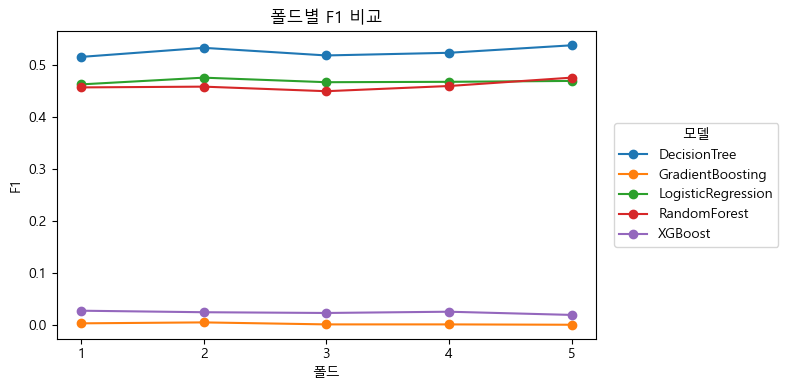

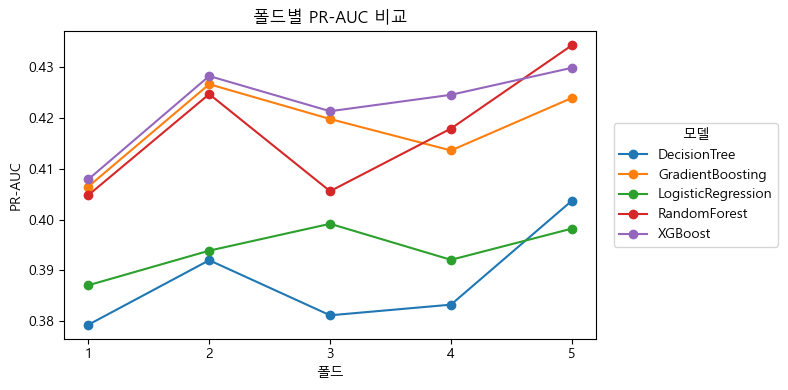

In [25]:
# ============================================================
# 9. fold별 F1 / PR-AUC 시각화
# ============================================================
metrics_to_plot = ["f1", "pr_auc"]
metric_label_map = {
    "f1": "F1",
    "pr_auc": "PR-AUC"
}

for metric in metrics_to_plot:
    pivot_df = cv_result_df.pivot(index="fold", columns="model", values=metric)

    plt.figure(figsize=(8, 4))
    for col in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[col], marker="o", label=col)

    plt.title(f"폴드별 {metric_label_map[metric]} 비교")
    plt.xlabel("폴드")
    plt.ylabel(metric_label_map[metric])
    plt.xticks(pivot_df.index)

    plt.legend(
        title="모델",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()
    plt.show()

### [ 해석 ]

- baseline 평균 성능 기준에서는 `DecisionTree`가 가장 강한 높은 성능을 보였다.
- 재현율은 `0.8244`, F1은 `0.5266`으로 가장 높게 나타나 churn 고객을 가장 잘 포착하는 baseline 모델이었다.
- `LogisticRegression`도 비교적 무난한 기준선 역할을 했고, `RandomForest`는 baseline 절대 성능은 중간 수준이었지만 이후 튜닝을 통해 개선 가능성이 있는 후보로 볼 수 있다.

## [ fold별 성능 확인 ]

- 목적: 모델별 성능이 fold마다 얼마나 흔들리는지 확인한다.
- 목표: 평균 성능뿐 아니라 변동성까지 함께 보고, 더 안정적인 후보를 판단한다.


In [13]:
# ============================================================
# 10. RandomForest 간단 튜닝
# ============================================================
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 8, 12],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [3, 5]
}

rf_tuning_results = []

for params in ParameterGrid(param_grid):
    rf_tuned_pipe = Pipeline([
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("model", RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ])

    tuned_cv_df = run_group_kfold_cv(
        model_pipeline=rf_tuned_pipe,
        X=X,
        y=y,
        groups=groups,
        n_splits=5,
        model_name="RandomForest_tuned"
    )

    summary = {
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "accuracy_mean": tuned_cv_df["accuracy"].mean(),
        "precision_mean": tuned_cv_df["precision"].mean(),
        "recall_mean": tuned_cv_df["recall"].mean(),
        "f1_mean": tuned_cv_df["f1"].mean(),
        "roc_auc_mean": tuned_cv_df["roc_auc"].mean(),
        "pr_auc_mean": tuned_cv_df["pr_auc"].mean()
    }
    rf_tuning_results.append(summary)

rf_tuning_df = pd.DataFrame(rf_tuning_results)
rf_tuning_df = rf_tuning_df.sort_values(["f1_mean", "recall_mean", "pr_auc_mean"], ascending=False).reset_index(drop=True)

rf_tuning_display_df = rf_tuning_df.rename(columns={
    "n_estimators": "트리 개수",
    "max_depth": "최대 깊이",
    "min_samples_split": "분할 최소 샘플 수",
    "min_samples_leaf": "리프 최소 샘플 수",
    "accuracy_mean": "정확도 평균",
    "precision_mean": "정밀도 평균",
    "recall_mean": "재현율 평균",
    "f1_mean": "F1 평균",
    "roc_auc_mean": "ROC-AUC 평균",
    "pr_auc_mean": "PR-AUC 평균"
})

display(rf_tuning_display_df.head(10))


,트리 개수,최대 깊이,분할 최소 샘플 수,리프 최소 샘플 수,정확도 평균,정밀도 평균,재현율 평균,F1 평균,ROC-AUC 평균,PR-AUC 평균
0,300,8.0,10,3,0.511369,0.403690,0.726159,0.518748,0.578479,0.419237
1,200,8.0,5,5,0.510836,0.403324,0.726213,0.518494,0.577854,0.418751
2,200,8.0,10,5,0.510836,0.403324,0.726213,0.518494,0.577854,0.418751
3,300,8.0,5,5,0.510666,0.403133,0.725611,0.518208,0.578301,0.419093
4,300,8.0,10,5,0.510666,0.403133,0.725611,0.518208,0.578301,0.419093
5,200,8.0,10,3,0.511659,0.403624,0.723800,0.518085,0.578020,0.418906
6,300,8.0,5,3,0.511853,0.403640,0.723212,0.517998,0.578715,0.418985
7,200,8.0,5,3,0.511465,0.403440,0.723600,0.517937,0.578744,0.418924
8,200,12.0,10,3,0.530401,0.409194,0.662330,0.505715,0.581227,0.421955
9,300,12.0,10,3,0.529698,0.408743,0.663147,0.505633,0.581042,0.421922


## [ RandomForest 튜닝 결과 ]

- 목적: RandomForest의 하이퍼파라미터 조합별 성능을 비교한다.
- 목표: baseline RF보다 `F1`과 `재현율`이 실제로 개선되는 조합을 찾는다.


In [14]:
# ============================================================
# 11. 최적 파라미터 선택
# ============================================================
best_params = rf_tuning_df.iloc[0].to_dict()
best_params

{'n_estimators': 300.0,
 'max_depth': 8.0,
 'min_samples_split': 10.0,
 'min_samples_leaf': 3.0,
 'accuracy_mean': 0.5113685473943314,
 'precision_mean': 0.40369031258126203,
 'recall_mean': 0.7261590397641151,
 'f1_mean': 0.5187475654614935,
 'roc_auc_mean': 0.5784791184219896,
 'pr_auc_mean': 0.41923738827323}

### [ 해석 ]

- 최적 조합은 `n_estimators=300`, `max_depth=8`, `min_samples_split=10`, `min_samples_leaf=3`으로 선택되었다.
- 이는 트리 수를 충분히 확보하면서도 깊이와 리프 크기를 제한해 과도한 복잡도를 억제한 조합으로 볼 수 있다.
- 실제로 이 조합에서 `RandomForest`의 F1은 `0.4608 → 0.5187`, 재현율은 `0.5230 → 0.7262`로 baseline 대비 분명하게 개선되었다.

## [ 최적 파라미터 확인 ]

- 목적: 튜닝 표에서 선택된 최적 조합을 확인한다.
- 목표: 아래 전체 데이터 재학습 셀에 그대로 사용할 최종 파라미터를 확정한다.


In [15]:
# ============================================================
# 12. 최적 RandomForest로 전체 데이터 재학습
# ============================================================
best_rf_pipe = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", RandomForestClassifier(
        n_estimators=int(best_params["n_estimators"]),
        max_depth=None if pd.isna(best_params["max_depth"]) else int(best_params["max_depth"]),
        min_samples_split=int(best_params["min_samples_split"]),
        min_samples_leaf=int(best_params["min_samples_leaf"]),
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

best_rf_pipe.fit(X, y)

rf_model = best_rf_pipe.named_steps["model"]
rf_feature_names = get_transformed_feature_names(best_rf_pipe)

importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_display_df = importance_df[["feature", "importance"]].copy()
importance_display_df.columns = ["변수", "중요도"]

display(importance_display_df.head(20))

,변수,중요도
19,월평균 휴대폰 이용 총 금액,0.174921
20,월평균 기기 할부금,0.145497
17,개인 월평균 소득,0.137948
18,연령대,0.130139
1,스마트폰 구분=2.0,0.086166
2,스마트폰 구분=3.0,0.073438
14,휴대폰 결합상품 가입 여부=1.0,0.028951
13,휴대폰 결합상품 가입 여부=0.0,0.028001
3,스마트폰 구분=4.0,0.024053
11,데이터 무제한 서비스 가입 여부=0.0,0.022103


### [ 해석 ]

- 위 표는 전처리 후 세부 feature 기준 중요도이므로 `스마트폰 구분=2.0`, `휴대폰 결합상품 가입 여부=1.0`처럼 값별로 나뉘어 나타나는 것이 정상이다.
- 즉 범주형 변수들은 모델 학습 단계에서 세부 범주별 더미 변수로 분리되어 중요도가 계산된다.
- 따라서 최종 변수 해석은 바로 아래의 `원변수 기준 합산 결과`를 사용하는 것이 더 적절하다.

## [ 세부 feature 기준 중요도 ]

- 목적: 최적 RandomForest가 실제로 어떤 전처리 후 feature에 크게 반응했는지 확인한다.
- 목표: 세부 feature 중요도를 먼저 확인하되, 최종 해석은 바로 아래 원변수 기준 합산 결과를 사용한다.


,변수,중요도
0,스마트폰 구분,0.192096
1,월평균 휴대폰 이용 총 금액,0.174921
2,월평균 기기 할부금,0.145497
3,개인 월평균 소득,0.137948
4,연령대,0.130139
5,휴대폰 결합상품 가입 여부,0.056952
6,휴대폰 요금 부담자,0.054527
7,데이터 무제한 서비스 가입 여부,0.043890
8,음성 무제한 서비스 가입 여부,0.035031
9,직업 유무,0.028998


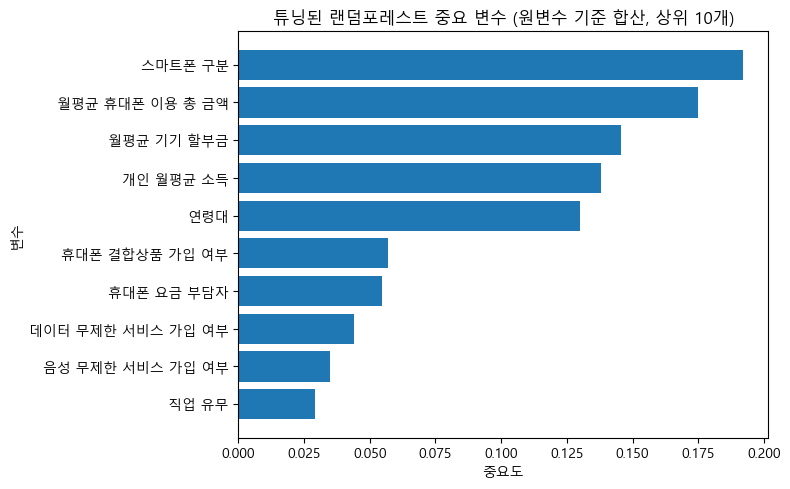

In [16]:
# ============================================================
# 12-1. 원변수 기준 중요도 합산 및 시각화
# ============================================================
def map_to_display_base_feature(feature_name):
    if "=" in feature_name:
        return feature_name.split("=")[0].strip()
    return feature_name

importance_grouped_df = (
    importance_df.assign(base_feature=importance_df["feature"].apply(map_to_display_base_feature))
    .groupby("base_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_grouped_df["base_feature"] = importance_grouped_df["base_feature"].map(
    lambda x: FEATURE_LABEL_MAP.get(x, x)
)

importance_grouped_display_df = importance_grouped_df.rename(columns={
    "base_feature": "변수",
    "importance": "중요도"
})

display(importance_grouped_display_df)

plot_df = importance_grouped_display_df.head(10).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["변수"], plot_df["중요도"])
plt.title("튜닝된 랜덤포레스트 중요 변수 (원변수 기준 합산, 상위 10개)")
plt.xlabel("중요도")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

### [ 해석 ]

- 원변수 기준으로 중요도를 다시 합산하면 `스마트폰 구분`, `월평균 휴대폰 이용 총 금액`, `월평균 기기 할부금`, `개인 월평균 소득`, `연령대` 순으로 중요도가 높게 나타났다.
- 여기서 `스마트폰 구분`이 가장 높게 나타난 것은 세부 범주별 중요도가 합쳐진 결과이므로, 단일 더미 변수 하나가 압도적이었다기보다 스마트폰 구분 관련 정보 전체가 중요한 신호로 작용했다고 해석하는 것이 적절하다.
- 즉 churn_any는 단말 특성, 통신 이용 특성, 비용 부담, 경제적 여건, 연령대가 함께 작용하는 문제로 볼 수 있다.

## [ 원변수 기준 중요도 ]

- 목적: 세부 feature 중요도를 원래 변수 기준으로 다시 묶어 해석 가능한 형태로 정리한다.
- 목표: 보고서와 발표에서는 이 표와 그래프를 기준으로 주요 변수군을 해석한다.


In [17]:
# ============================================================
# 13. threshold 조정 함수
# ============================================================
def evaluate_by_threshold(y_true, y_proba, thresholds):
    rows = []

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        rows.append({
            "threshold": th,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    return pd.DataFrame(rows)

In [18]:
# ============================================================
# 14. threshold 조정 예시용 hold-out 평가
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

best_rf_pipe.fit(X_train, y_train)
y_proba_test = best_rf_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)
threshold_df = evaluate_by_threshold(y_test, y_proba_test, thresholds)

threshold_display_df = threshold_df.rename(columns={
    "threshold": "임계값",
    "precision": "정밀도",
    "recall": "재현율",
    "f1": "F1"
})

display(threshold_display_df)


,임계값,정밀도,재현율,F1
0,0.10,0.353076,1.000000,0.521886
1,0.15,0.353076,1.000000,0.521886
2,0.20,0.353253,0.999659,0.522033
3,0.25,0.354414,0.999318,0.523253
4,0.30,0.355683,0.996591,0.524258
5,0.35,0.360590,0.983294,0.527674
6,0.40,0.369603,0.948517,0.531931
7,0.45,0.381938,0.886805,0.533922
8,0.50,0.395525,0.729287,0.512888
9,0.55,0.465608,0.090010,0.150857


### [ 해석 ]

- 임계값이 낮아질수록 재현율은 높아지고 정밀도는 낮아지는 전형적인 흐름이 확인된다.
- 현재 결과에서는 `0.45`에서 F1이 가장 높았고, `0.40 ~ 0.45` 구간에서 재현율과 F1의 균형이 상대적으로 좋게 형성되었다.
- churn_any 문제에서는 고객을 놓치지 않는 방향이 중요하므로, 정밀도만 보기보다 재현율과 F1을 함께 보는 것이 적절하다.

## [ threshold 비교표 ]

- 목적: hold-out 기준으로 threshold별 정밀도, 재현율, F1 변화를 비교한다.
- 목표: churn 고객을 덜 놓치는 방향에서 어떤 threshold가 가장 균형적인지 확인한다.


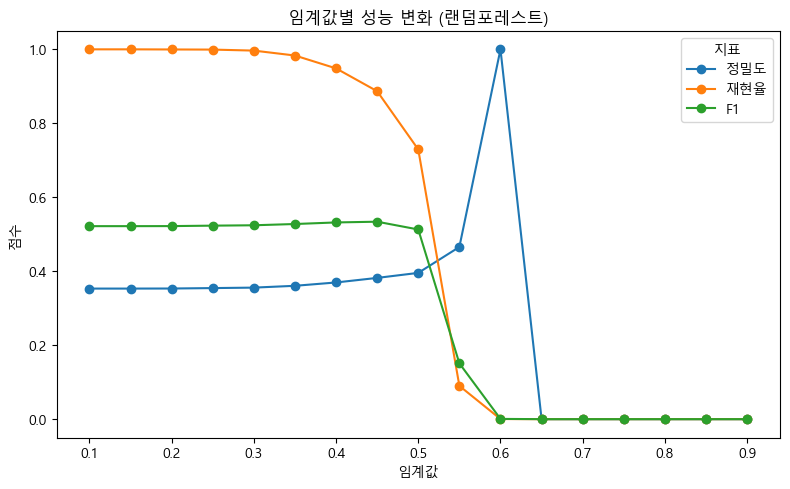

In [19]:
# ============================================================
# 15. threshold별 precision / recall / f1 시각화
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="정밀도")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="재현율")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")

plt.title("임계값별 성능 변화 (랜덤포레스트)")
plt.xlabel("임계값")
plt.ylabel("점수")
plt.legend(title="지표")
plt.tight_layout()
plt.show()


### [ 해석 ]

- 그래프가 완만하게 변하지 않고 `0.45` 부근까지 유지되다가 `0.50` 이후 급격히 꺾이는 모습은 현재 튜닝된 RandomForest의 예측 확률이 특정 구간에 몰려 있음을 보여준다.
- 따라서 이 그래프는 비정상적으로 그려진 것이 아니라, 모델이 양성 확률을 주로 `0.4 ~ 0.5` 부근에 집중해서 부여한 결과를 반영한 것이다.
- 실제로 `0.45`에서 F1이 가장 높았고, 운영 목적상 재현율을 조금 더 중시하면 `0.40`도 후보가 될 수 있다.

## [ threshold 시각화 ]

- 목적: threshold 변화에 따라 정밀도, 재현율, F1이 어떻게 달라지는지 한눈에 확인한다.
- 목표: 숫자 표와 함께 시각적으로도 최적 구간을 판단한다.


In [24]:
# ============================================================
# 16. Best Threshold Summary
# ============================================================
best_threshold = (
    threshold_df
    .sort_values("f1", ascending=False)
    .iloc[0]["threshold"]
)

y_pred_best = (y_proba_test >= best_threshold).astype(int)

best_threshold_row = pd.DataFrame([{
    "model": "RandomForest",
    "model Type": "Bagging Ensemble",
    "threshold": best_threshold,
    "accuracy": accuracy_score(y_test, y_pred_best),
    "precision": precision_score(y_test, y_pred_best, zero_division=0),
    "recall": recall_score(y_test, y_pred_best, zero_division=0),
    "f1": f1_score(y_test, y_pred_best, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_test),
    "pr_auc": average_precision_score(y_test, y_proba_test)
}]).round(4)

best_threshold_row = best_threshold_row[
    ["model", "model Type", "threshold", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
].reset_index(drop=True)

display(best_threshold_row)

,model,model Type,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,RandomForest,Bagging Ensemble,0.45,0.4534,0.3819,0.8868,0.5339,0.5868,0.422


### [ 해석 ]

- 최적 임계값은 `0.45`이며, 이때 `정밀도 0.3819`, `재현율 0.8868`, `F1 0.5339`를 기록했다.
- 이는 churn 고객을 가능한 한 놓치지 않으면서도 일정 수준의 정밀도를 유지하는 균형점으로 해석할 수 있다.
- baseline 비교와 튜닝 결과를 함께 보면, 최종 `RandomForest`는 churn_any 문제에서 실제 활용 가능한 모델로 정리할 수 있다.

## [ 최적 임계값 요약 ]

- 목적: threshold 비교 결과 중 가장 균형적인 지점을 한 줄로 요약한다.
- 목표: 최종 요약 문장에 바로 옮길 수 있는 형태로 정리한다.


In [21]:
# ============================================================
# 추가. 최종 종합 비교표
# ============================================================
cv_mean_df = (
    cv_result_df
    .groupby("model")[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
    .mean()
    .round(4)
    .reset_index()
)

cv_mean_df["model_type"] = cv_mean_df["model"].map({
    "LogisticRegression": "선형 모델",
    "DecisionTree": "단일 트리",
    "RandomForest": "배깅 앙상블",
    "GradientBoosting": "부스팅 앙상블",
    "XGBoost": "실무형 부스팅"
})

cv_mean_final_display_df = cv_mean_df.rename(columns={
    "model": "모델",
    "model_type": "모델 유형",
    "accuracy": "정확도",
    "precision": "정밀도",
    "recall": "재현율",
    "f1": "F1",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC"
})

cv_mean_final_display_df = cv_mean_final_display_df[["모델", "모델 유형", "정확도", "정밀도", "재현율", "F1", "ROC-AUC", "PR-AUC"]]
cv_mean_final_display_df = cv_mean_final_display_df.sort_values(["F1", "재현율", "PR-AUC"], ascending=False).reset_index(drop=True)

display(cv_mean_final_display_df)


,모델,모델 유형,정확도,정밀도,재현율,F1,ROC-AUC,PR-AUC
0,DecisionTree,단일 트리,0.4625,0.3870,0.8244,0.5266,0.5471,0.3879
1,LogisticRegression,선형 모델,0.5245,0.3943,0.5795,0.4692,0.5512,0.3941
2,RandomForest,배깅 앙상블,0.5561,0.4119,0.5230,0.4608,0.5739,0.4175
3,XGBoost,실무형 부스팅,0.6369,0.4899,0.0121,0.0236,0.5834,0.4224
4,GradientBoosting,부스팅 앙상블,0.6370,0.4523,0.0009,0.0017,0.5791,0.4181


### [ 해석 ]

- baseline 기준으로는 `DecisionTree`가 가장 높은 재현율과 F1을 보였다.
- 그러나 튜닝된 `RandomForest`는 baseline RandomForest 대비 성능이 뚜렷하게 개선되었고, threshold 조정을 통해 활용 가능성도 확인되었다.
- 따라서 최종 정리에서는 `baseline 최고 성능 = DecisionTree`, `튜닝 후 주요 활용 모델 = RandomForest`로 구분해 쓰는 것이 가장 정확하다.

## [ baseline 종합 비교표 ]

- 목적: baseline 모델들의 평균 성능을 한 번 더 정리해 전체 흐름을 마무리한다.
- 목표: baseline 성능과 튜닝 결과를 연결해서 최종 모델 선택 근거를 정리한다.


## [ 결과 해석 정리 ]

`churn_any` 모델링은 `baseline 비교 → RandomForest 튜닝 → 중요도 확인 → threshold 조정` 흐름으로 진행하였다.

이 노트북의 baseline 비교는 GroupKFold 평균 기준이므로, `02`의 단일 hold-out baseline과 직접 같은 수치로 비교하면 안 된다.

baseline 비교에서는 `DecisionTree`가 `재현율 0.8244`, `F1 0.5266`으로 가장 강한 성능을 보였다.
`LogisticRegression`도 비교적 무난한 성능을 보였고, `RandomForest`는 baseline 기준 절대 1위는 아니었지만 `ROC-AUC`와 `PR-AUC`가 비교적 안정적이어서 튜닝 후보로 삼을 만한 모델이었다.
즉 `04`의 baseline 해석은 GroupKFold 평균 기준에서 `DecisionTree`가 가장 높은 성능을 보인 모델로 정리하는 것이 적절하다.

튜닝 결과, 최적 `RandomForest`는 `n_estimators=300`, `max_depth=8`, `min_samples_split=10`, `min_samples_leaf=3` 조합으로 선택되었다.
이 조합에서 `F1은 0.4608 → 0.5187`, `재현율은 0.5230 → 0.7262`로 baseline RandomForest 대비 분명한 개선이 확인되었다.
즉 baseline 절대 1위 모델은 아니었지만, 튜닝을 통해 실제 활용 가능한 수준까지 성능을 끌어올린 것으로 해석할 수 있다.

세부 feature 중요도에서는 범주형 변수가 값별로 나뉘어 나타났기 때문에, 최종 해석은 원변수 기준 합산 결과를 중심으로 진행하였다.
원변수 기준 중요도 합산 결과에서는 `스마트폰 구분`, `월평균 휴대폰 이용 총 금액`, `월평균 기기 할부금`, `개인 월평균 소득`, `연령대`가 상대적으로 중요한 변수로 나타났다.
특히 `스마트폰 구분`이 가장 높게 나타난 것은 세부 범주별 중요도가 합쳐진 결과이므로, 특정 값 하나보다 스마트폰 구분 관련 정보 전체가 중요한 신호로 작용했다고 해석하는 것이 적절하다.

hold-out 기준 threshold를 비교한 결과, `임계값 0.45`에서 `정밀도 0.3819`, `재현율 0.8868`, `F1 0.5339`로 가장 좋은 균형을 보였다.
또한 threshold 그래프는 `0.45` 부근까지는 성능 균형이 유지되다가 `0.50` 이후 급격히 꺾이는 모습을 보였는데, 이는 현재 튜닝된 RandomForest의 예측 확률이 특정 구간에 몰려 있음을 보여준다.
따라서 현재 모델은 churn 고객을 가능한 한 놓치지 않으면서도 일정 수준의 정밀도를 유지하려는 목적에 적합한 후보로 볼 수 있다.
다만 이 threshold는 단일 hold-out split 기준이므로, 실제 적용 시에는 운영 목적과 데이터 분할에 따라 다시 조정할 필요가 있다.

정리하면, `04`에서는 baseline 최고 성능은 `DecisionTree`, 튜닝 후 주요 활용 모델은 `RandomForest`로 정리하는 것이 가장 정확하다.
